In [68]:
# Setup python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import clean
import models

# read in data
df = pd.read_csv("../data/TBI-PUD-10-08-2013.csv")

# set random seed and do train-validate-test split
np.random.seed(214)
dtrain, dvalidate, dtest = models.train_validation_test(df)

# Introduction

The premise of this data analysis is to reduce the unnecessary use of Computed Tomography (CT) scans used on pediatric patients when attempting to diagnose clinically-important Traumatic Brain Injuries (ciTBI). This is building off of an analysis done by Kupperman et al. (2009) in The Lancet. I will note here that Kupperman et al. define a ciTBI as follows: clinically-important TBI is defined as a priori as death from TBI, neurosurgery, intubation (assisted breathing) for more than 24 hours for TBI, or hospital admission of two or more nights for the TBI in association with TBI on CT.
\

When a pediatric patient is presenting to an emergency department with a traumatic brain injury (TBI), the health-care specialist must make a difficult decision. They must weigh the risks of addressing the immediate threat to the child by performing a CT scan against the long-run risk to the future adult that comes with exposure to radiation at such a young age. An effect that disproportionately affects women over men. 
\

The goal of Kupperman et al. was to identify a clinical decision rule (CDR) that can be used in the field to help make this decision. Specifically, to try and better predict when the CT scan could be obviated in patients at very low risk of ciTBI. CT scans are the predominant way of testing for TBI's. They are fast, don't require the patient be still for an extended period, and can see things that an MRI cannot. The number of CT scans has been on the rise, and the use of CT scans to diagnose TBI's in pediatric patients is higher in general emergency departments than in specifically pediatric emergency departments.
\

Better understanding the relationship between the features present in the dataset, and coming up with an interpretable model, would give health-care specialists the ability to more confidently obviate a CT scan in favor of the patient's long-term health. In the moment, when the current dangers feel overwhelming, it would be helpful to have an industry standard rule for making this decision. Especially in cases when the patient is pre-verbal and is not able to communicate. This report will attempt to present the data in an interpretable way, highlight some key findings, and rank the CDR implemented by Kupperman et al., logistic regression, and _____________________ in terms of accuracy and usability.

# Data

## Data Description

The data we will be analysing is the result of a prospective cohort study of patients younger than 18 years of age with head trauma in 25 emergency departments of the Pediatric Emergency Care Applied Research Network (PECARN). Patients were enrolled in the study from June 2004 to March 2006. In total, there were 43,399 patients enrolled in the study and whose observations are present in the dataset. The dataset has 125 features, but not all features are present for each patient. Many features have a specific code to represent "not applicable," which is different from the standard `NaN` that represents missing data.
\

Many of the features are dependent on each other, or can be grouped into various categories: See figure \ref{fig:dataset_bubbles} on the next page. For example, if the patient was experiencing vomiting, there are additional variables that measure the intensity. such as, how many episodes of vomiting? When did it start? When was the last episode? There are also various measurements to summarize the patient's responsiveness to stimuli, these are represented in the figure by the Glasgow Coma Scale (GCS) score. The scale is from 1-15, with lower numbers representing more severe head trauma. The scale is slightly different for patients that are under two years old. On that note, there are features that are not recorded if the patient is under two years old: amnesia, headache, and dizziness.

\begin{figure}[ht]
\centering
\scalebox{0.5}{
\begin{tikzpicture}[
    bubble/.style={circle, draw, align=center, minimum width=2.8cm},
    bigbubble/.style={circle, draw, align=center, minimum width=4cm, font=\bfseries}
]

% Main categories
\node[bigbubble] (patient) {Patient\\Information};

\node[bigbubble, above right=4cm and 5cm of patient] (symptoms) {Symptoms};

\node[bigbubble, below right=4cm and 5cm of symptoms] (ct) {CT Scan};

\node[bigbubble, below=8cm of symptoms] (outcome) {ciTBI};



% Patient sub-bubbles
\node[bubble, below left=1.06cm and 1.06cm of patient] (age1) {Age};
\node[bubble, below=1.5cm of patient] (age2) {Older than\\2 years?};
\node[bubble, below right=1.06cm and 1.06cm of patient] (behavior) {Acting\\Normal?};
\node[bubble, left=1.5cm of patient] (gender) {Gender};
\node[bubble, above left=1.06cm and 1.06cm of patient] (race) {Race};
\node[bubble, above=1.5cm of patient] (loc) {History of\\Loss of\\Consciousness};

% Symptoms sub-bubbles
\node[bubble, below left=1.06cm and 1.06cm of symptoms] (s1) {Headache};
\node[bubble, below=1.5cm of symptoms] (s2) {Vomiting};
\node[bubble, below right=1.06cm and 1.06cm of symptoms] (s3) {Dizziness};
\node[bubble, above=1.5cm of symptoms] (s31) {Glasgow Coma\\Scale (GCS)};
\node[bubble, above right=1.06cm and 1.06cm of symptoms] (s32) {Basilar Skull\\Fracture};
\node[bubble, above left=1.06cm and 1.06cm of symptoms] (s4) {Hematoma or\\Swelling};

% CT sub-bubbles
\node[bubble, below left=1.06cm and 1.06cm of ct] (c1) {Why was CT\\Ordered?};
\node[bubble, below=1.5cm of ct] (c2) {Found Cerebral\\Hemmorage};
\node[bubble, below right=1.06cm and 1.06cm of ct] (c3) {Found Diastasis\\of the Skull};
\node[bubble, right=1.5cm of ct] (c4) {Found Traumatic\\Infarction};
\node[bubble, above right=1.06cm and 1.06cm of ct] (c4) {Found Shift of\\Brain Structures};
\node[bubble, above=1.5cm of ct] (c5) {Under Sedation\\During Scan};

% Connecting lines
\foreach \x in {age1,age2,loc,gender,race,behavior}
    \draw (patient) -- (\x);

\foreach \x in {s1,s2,s3,s31,s32,s4}
    \draw (symptoms) -- (\x);

\foreach \x in {c1,c2,c3,c4,c5}
    \draw (ct) -- (\x);

\end{tikzpicture}
}
\caption{Examples of observations included in the dataset. (not complete picture) }
\label{fig:dataset_bubbles}
\end{figure}

This Data is exactly what we would need to construct our model to better predict when a CT scan is not needed. We have a lot of information regarding the pediatric patients that are brought into emergency rooms. It turns out that, by design, most of the dataset involves patients with a GCS of 14-15, meaning they are responsive and aren't obviously presenting symptoms of a ciTBI. If we can use this dataset to generate an accurate model that predicts from these patients whether they actually do have a ciTBI, then we could potentially deploy the model and decrease the number of extraneous CT scans.


## Data Collection

A good amount of the data was collected on site in the 25 emergency departments. Children presenting within 24 h of head trauma were eligible. Some exceptions include, children with trivial injury mechanisms, patients with known brain tumors, or patients that had already had neural imaging done at a different facility. Trained site investigators and other emergency department physicians recorded observations on a standardized data sheet. At times, a second assessment would be done within 60 minutes of the first. CT scans were interpreted by an on-site radiologist. To identify potentially missed traumatic brain injuries, research coordinators performed standardized telephone surveys of guardians of patients 7 to 90 days after the emergency department visit. If the guardian(s) could not be reached, available records were reviewed to ensure that no discharged patient was subsequently diagnosed with ciTBI. This included county morgue records.
\

All of the data has been encoded in numeric form. For example, `gender` is encoded as `1: male`, `2: female`, and `Finding 1` (cerebellar hemorrhage found during brain scan) is encoded as `0: No`, `1: Yes`, `92: Not Applicable`. `Finding 1` would be listed as `92` if a patient was never given a CT scan. In general, the specific encodings for other options are: `92: Not Applicable` is placed in a feature that is not used for that patient, `91: Pre-verbal/Non-verbal` is the catch all code for the patient is not speaking, and `90: Other` is used when describing something that does not fit into the features preset list of categories. For example, `EDDisposition` (the patient's next destination) is stored as the numbers 1 - 8, then 90: `1: Home`, `2: OR`, `3: Admit - general inpatient`, etc. Now that the data collection process and the structure of the data has been explained, we can now look at the ways in which this data may not be in a state to do modelling just yet. 




## Data Cleaning

This data is not clean, and arguably is not "tidy" either. By including the `92` option, we are now distinguishing between not-applicable and `NaN` (missing data), but we already have a way of knowing if something was not applicable. e.g. why do we need `92` for `VomitNbr` (number of vomiting episodes since injury) in that variable to tell us that another variable (`Vomit`) was marked as `0: No`. Choosing to encode the data in this way is a little confusing, and produces outliers in the dataset that will skew our model. Having many large values for `VomitNbr` actually skews the mean and artificially inflates the importance of this and other variables like it. We run into similar problems for the variables containing `90` and `91` as well.
\

We can also look more closely at the amount of missing/inconsistent data. In my training split, I was able to find 32,552 missing values overall. The two features with the most missing data being `Dizzy` (a yes or no variable) and `Ethnicity` (Hispanic or Non-Hispanic). Each of these can be assumed to mean that the site investigator could not get a definitive answer from either the patient or their guardian(s). See figure \ref{fig-missing-extreme} for some specific details. 


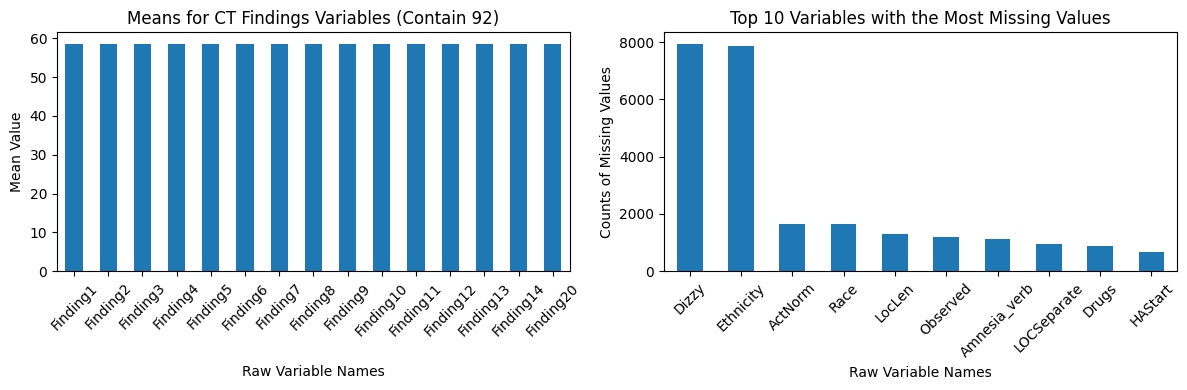

In [69]:
#| label: fig-missing-extreme
#| fig-cap: "Consequences of Extreme/Missing Values in Training Dataset"
#| fig-width: 5
#| fig-height: 3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

dtrain.isnull().sum().sort_values(ascending=False).head(10).plot.bar(ax=ax2)
ax2.set_xlabel("Raw Variable Names")
ax2.set_ylabel("Counts of Missing Values")
ax2.set_title("Top 10 Variables with the Most Missing Values")
ax2.tick_params(axis='x', rotation=45)

dtrain.loc[:, 'Finding1':'Finding20'].mean().plot.bar(ax=ax1)
ax1.set_xlabel("Raw Variable Names", labelpad = 19)
ax1.set_ylabel("Mean Value")
ax1.set_title("Means for CT Findings Variables (Contain 92)")
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()


In some good news, I did not find any values that were mislabeled when they should have been `92`. i.e. For all of the dependencies, when the required variable was `0`, the extra variable was `92` (or missing) indicating it was not applicable. My final comment will be that the variable names themselves are inconsistent and not interpretable to someone with limited domain knowledge. Why is it written `HA_verb`, but a later variable is `HAStart` (no underscore). Similarly, I had to look up `EDDisposition` as it is assumed the reader of the data dictionary knows what that is.

## Data Cleaning

The data cleaning process will follow these basic steps:

| Step | Action | Justification |
|------|--------|---------------|
| 1 | Remove rows with GCS less than 14 and missing `PosIntFinal` | This mirrors the Kupperman et al. article. We are only interested in becoming better at obviating CT scans for patients with little to no risk of ciTBI, so we will use the GCS score as our estimator for that risk. Second, the few datapoints that are missing the primary outcome will not be useful in our analysis as they do not have a response variable for us to compare our prediction to. |
|||---------------|
| 2 | Create `verbal` indicator feature from `92` (0 is "pre-verbal/non-verbal", 1 is "responsive") | This specific encoding (`92`) held easily accessible information, and so I believe it should be its own variable. I believe that a domain expert would agree with this replacement. |
|||---------------|
| 3 | Replace the encodings `90`, `91`, and `92` with `0`, `np.nan`, and `np.nan` respectivley | This forces one method of missing or not-applicable data. `90` is replaced with `0` instead of `NaN` because the "Other" it represents category still contains some relevant information, we just want it to be on the same relative scale as the other levels in the categorical data. Additionaly, `92` is now its own feature, which means that `92` now represents missing information. |
|||---------------|
| 4 | Check that there are no inconsistencies between dependent features. For example, if `Vomit` is marked as `0`, but `VomitNbr` is marked at `2` | While I could not find any observations like this in my ad-hoc exploration, that does not mean that it is not present in the validation or test data (or real, future data). Therefore, we should protect against that inconsistency. Note that I am choosing to prioritize the global variable over the dependent if a disagreement arises. |
|||---------------|
| 5 | Standardize column names to lowercase without underscores | Improves consistency across the dataset, makes analysis easier if all column names follow the same structure |


Above are the explicit steps made in the data cleaning process. You can look at `clean.py` in the `code/` directory to see how I implemented those steps in code. However, there are is one main implied judgement call that I must make clear. I have decided that it is acceptable for the cleaned dataset to contain missing values. The main reason for this is that when I explored the training data (which you can follow in `lab-1-explore.ipynb` in the `code/` directory) there were many missing values. Importantly, a key feature has many missing values: `Ethnicity`. Recall that `Ethnicity` is either `1: Hispanic`or `2: Non-Hispanic`.
\

I did not feel comfortable imputing this variable with the mode or median. Doing so would assign the missing values to the majority ethnicity, which is not reflective of reality. Additionally, forcefully erasing minority ethnicities is not very kosher. However, If I tried to use the mean, then I am imputing it with a non-interpretable value: something between 1 and 2. I could even try and make the portion of the patients with missing ethnicities match the portions in the rest of the data, but then I am assigning ethnicities randomly and is that really better than just not having it in the first place? Lastly, I did not feel comfortable removing all of the patients whose ethnicities are missing, because as you can see in figure \ref{fig-missing-extreme} it's almost 8000 patients, which with a 50\% train split is roughly 1/3 of the training data.

In [70]:
ctrain = clean.clean_data(dtrain)

\newpage

## Data Exploration (On Clean Data)

Now that we have defined the data cleaning process, we can start looking at relationships among variables in the clean dataset. We can start by looking at the distributions of the patients.

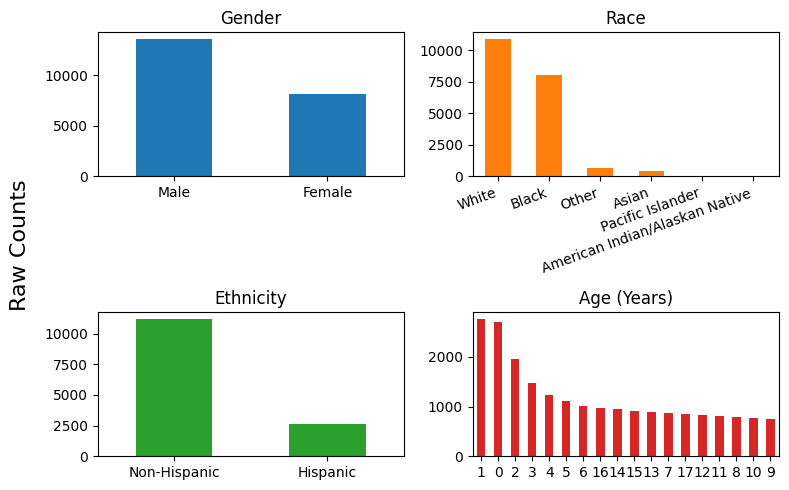

In [71]:
#| label: fig-patient-distribution
#| fig-cap: "Counts of Patients by Gender, Race, Ethnicity, and Age"
#| fig-width: 1.5
#| fig-height: .5

agg_gender = ctrain["gender"].value_counts()
agg_race = ctrain["race"].value_counts()
agg_eth = ctrain["ethnicity"].value_counts()
agg_age = ctrain["ageinyears"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
ax = axes.ravel()

agg_gender.plot(kind="bar", ax=ax[0], color="C0")
ax[0].set_title("Gender")
ax[0].set_xlabel("")
gender_map = {1: "Male", 2: "Female"}
ax[0].set_xticklabels([gender_map.get(int(x), str(x)) for x in agg_gender.index], rotation=0)

agg_race.plot(kind="bar", ax=ax[1], color="C1")
ax[1].set_title("Race")
ax[1].set_xlabel("")
race_map = {0: "Other", 1: "White", 2: "Black", 3: "Asian", 4: "American Indian/Alaskan Native", 5: "Pacific Islander"}
ax[1].set_xticklabels([race_map.get(int(x), str(x)) for x in agg_race.index], rotation=20, ha="right")

agg_eth.plot(kind="bar", ax=ax[2], color="C2")
ax[2].set_title("Ethnicity")
ax[2].set_xlabel("")
eth_map = {1: "Hispanic", 2: "Non-Hispanic"}
ax[2].set_xticklabels([eth_map.get(int(x), str(x)) for x in agg_eth.index], rotation=0)

agg_age.plot(kind="bar", ax=ax[3], color="C3")
ax[3].set_title("Age (Years)")
ax[3].set_xlabel("")
ax[3].set_xticklabels([str(int(x)) for x in agg_age.index], rotation=0)

fig.supylabel("Raw Counts", fontsize = 16)
plt.tight_layout()
plt.show()

Figure \ref{fig-patient-distribution} gives us a birds-eye view of the different types of patients that were presenting at these 25 emergency departments within 24 hours of a TBI. Predominantly Male, White, and young. However, if we look at the percentages of patients in these groups that receive a CT scan, we get a different story.
\

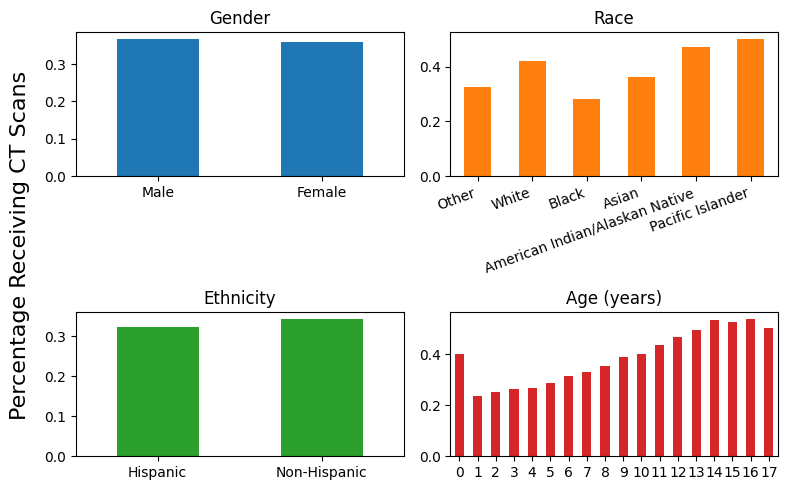

In [72]:
#| label: fig-distribution
#| fig-cap: "Percentages Receiving CT Scans for Gender, Race, Ethnicity, and Age"
#| fig-width: 1.5
#| fig-height: .5

tot_gender = ctrain["gender"].value_counts()
tot_race = ctrain["race"].value_counts()
tot_eth = ctrain["ethnicity"].value_counts()
tot_age = ctrain["ageinyears"].value_counts()

agg_gender = ctrain.groupby("gender")["ctdone"].sum() / tot_gender
agg_race = ctrain.groupby("race")["ctdone"].sum() / tot_race
agg_eth = ctrain.groupby("ethnicity")["ctdone"].sum() / tot_eth
agg_age = ctrain.groupby("ageinyears")["ctdone"].sum() / tot_age

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
ax = axes.ravel()

agg_gender.plot(kind="bar", ax=ax[0], color="C0")
ax[0].set_title("Gender")
ax[0].set_xlabel("")
gender_map = {1: "Male", 2: "Female"}
ax[0].set_xticklabels([gender_map.get(int(x), str(x)) for x in agg_gender.index], rotation=0)

agg_race.plot(kind="bar", ax=ax[1], color="C1")
ax[1].set_title("Race")
ax[1].set_xlabel("")
race_map = {0: "Other", 1: "White", 2: "Black", 3: "Asian", 4: "American Indian/Alaskan Native", 5: "Pacific Islander"}
ax[1].set_xticklabels([race_map.get(int(x), str(x)) for x in agg_race.index], rotation=20, ha="right")

agg_eth.plot(kind="bar", ax=ax[2], color="C2")
ax[2].set_title("Ethnicity")
eth_map = {1: "Hispanic", 2: "Non-Hispanic"}
ax[2].set_xticklabels([eth_map.get(int(x), str(x)) for x in agg_eth.index], rotation=0)
ax[2].set_xlabel("")

agg_age.plot(kind="bar", ax=ax[3], color="C3")
ax[3].set_title("Age (years)")
ax[3].set_xlabel("")
ax[3].set_xticklabels([str(int(x)) for x in agg_age.index], rotation=0)

fig.supylabel("Percentage Receiving CT Scans", fontsize = 16)
plt.tight_layout()
plt.show()

Somewhat surprisingly, in figure \ref{fig-distribution} on the next page there is an equal percentage of male and female patients that are receiving scans, similarly with Hispanic and Non-Hispanic patients. Although, we need to keep in mind that we are missing a lot of data when it comes to the ethnicity of patients. The high percentage of American Indian/Alaskan Native and Pacific Islander receiving CT scans can be attributed to their very low population count in the dataset, so it only takes a small number of CT scans to boost their percentage. 
\

Lastly, in figure \ref{fig-distribution} it appears the trend in Age has reversed. In raw counts, the older you were, the fewer patients were presenting at the ED with TBI. However, the older the patient, the more likely they are to have received a CT scan. This may be due to the lower perceived risk of long-term effects on older patients. With the exception of the increase for _very_ young patients. I imagine this is due to them being unable to communicate and the fact that they are more fragile, so a CT scan may be the best/fastest way to ascertain if there is immediate physical danger to the patient.

# Findings

Let's look at some more interesting data before we move on to creating our model.

## First finding

Describe it and place a figure here

## Second finding

Describe it and place a figure here

## Third finding

Describe it and place a figure here

## Reality Check

-   Do a reality check. What reality could you compare your cleaned data
    to?

-   Clearly state your assumptions and explain why this reality check is
    useful.

-   Does your cleaned data pass the reality check or are there issues?
    Discuss.

## Stability Check

Take one of your findings and present a perturbed version. How does this
affect your finding? Add a before and after plot here.

# Modeling

|||---------------|
| 2 | Drop `GCSTotal` column | It is the sum of the individual GCS measurements for eye, verbal, and motor. We can add it back if we need to make plots. |
|||---------------|
| 3 | Drop `AgeinYears` column | `AgeInMonths` provides finer resolution. We can always get it back by taking the floor of `AgeInMonth` when divided by 12. |

## Implementation

- Discuss any design choices that were made in the modeling stage.
    - Which algorithms did you use?
    - How did you determine hyperparameters?
- This should not drone on for too long, but give enough information that your implementation can be
replicated by a reader.


## Interpretability

Discuss the following:

- Is your model a simple interpretable form?
- If not, how do you recommend interpreting how it obtains the predictions it does?

If possible, include a figure or schematic that explains how one of your models works.

## Stability

Include a figure + discussion which examine how each model’s predictions/behavior changes under the data
perturbation from Section 3.5.

# Discussion

-   Did the data size restrict you in any way? Discuss some challenges
    that you faced as a result of the data size.

-   Address the three realms: data / reality, algorithms / models, and
    future data / reality.

-   Where do the parts of the lab fit into those three realms?

-   Do you think there is a one-to-one correspondence of the data and
    reality?

-   What about reality and data visualization?

# Conclusion

-   You should make attempts to connect your findings/analysis back to
    the domain problem in every section of this report, but here in the
    conclusion, you can reiterate your main points and provide
    overarching remarks on the PECARN data as it relates to the domain
    problem.

\newpage

# Academic Honesty

## Statement

To Professor Yu,
\

I attest that the work in this report is my own and that all sources are properly cited, including my classmates. Academic research honesty is necessary for the validity of scientific results. Without academic research honesty, we lose the veridicality of the facts that arise as a result of scientific research. If one, as a researcher, is dishonest regarding data or its sources then the results of one's research is no longer relevant. If a researcher takes from another without credit, then their overall credibility as a researcher is now in question. These concerns are why I believe academic research honesty is important.
\

Sincerely, 

your STAT 214 student.

## Collaborators

I discussed the project briefly with fellow students Victoria Karai, Tobias Roemer, and Abhishek Shukla. I leaned on AI to create a starting point for the figures present in the report, and asked it questions to help with debugging or to remind me what commands I could use to achieve my specific data needs.

## Bibliography

Kuppermann, Nathan, et al. “Identification of children at very low risk of clinically-important brain injuries after head trauma: A prospective cohort study.” The Lancet, vol. 374, no. 9696, 15 Sept. 2009, pp. 1160–1170, https://doi.org/10.1016/s0140-6736(09)61558-0. 
\

Jain S, Margetis K, Iverson LM. Glasgow Coma Scale. [Updated 2025 Jun 23]. In: StatPearls [Internet]. Treasure Island (FL): StatPearls Publishing; 2025 Jan-. Available from: https://www.ncbi.nlm.nih.gov/books/NBK513298/?report=classic
\

Shahi, Varun, et al. “Trends in CT utilization for pediatric fall patients in US emergency departments.” Academic Radiology, vol. 22, no. 7, 1 July 2015, pp. 898–903, https://doi.org/10.1016/j.acra.2015.02.016. 